# Chapter 159 — Determinants: Computation

> **Prerequisites:** Determinants intuition *(ch158)*, matrix multiplication *(ch154)*
> **You will learn:**
> - Cofactor expansion (Laplace expansion)
> - Determinant via LU decomposition (the efficient way)
> - Numerical stability issues for large n
> - The characteristic polynomial via det(A - λI)
>
> **Environment:** Python 3.x, numpy

n=2: cofactor=5.0000, numpy=5.0000, match=True
n=3: cofactor=0.0000, numpy=0.0000, match=True
n=3: cofactor=8.0000, numpy=8.0000, match=True

--- Characteristic polynomial ---


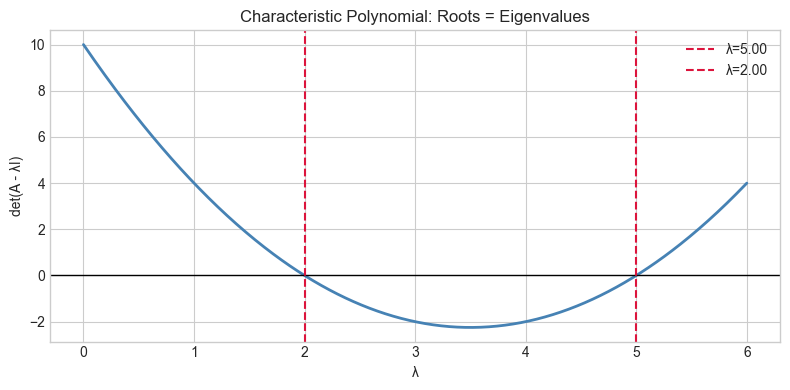

In [1]:
# --- Determinants: Cofactor expansion and LU method ---
import numpy as np

def det_cofactor(A):
    """
    Compute determinant via cofactor expansion along first row.
    Recursive, O(n!) — illustrative only, not for large matrices.

    Args:
        A: square 2D numpy array

    Returns:
        scalar determinant value
    """
    n = A.shape[0]
    if n == 1: return A[0, 0]
    if n == 2: return A[0,0]*A[1,1] - A[0,1]*A[1,0]
    det = 0.0
    for j in range(n):
        # Minor: delete row 0, column j
        minor = np.delete(np.delete(A, 0, axis=0), j, axis=1)
        cofactor = ((-1)**j) * det_cofactor(minor)
        det += A[0, j] * cofactor
    return det

def det_via_lu(A):
    """
    Compute determinant via LU decomposition.
    O(n³) and numerically stable.

    Args:
        A: square 2D numpy array

    Returns:
        scalar determinant value
    """
    # PA = LU; det(A) = det(P)⁻¹ * det(L) * det(U)
    # det(L) = product of diagonal (all 1s for unit lower triangular)
    # det(U) = product of diagonal entries
    # det(P) = (-1)^(number of swaps)
    import scipy.linalg
    P, L, U = scipy.linalg.lu(A)
    # Count permutation sign from P
    p_vec = np.argmax(P, axis=0)   # where each column sends the basis
    sign = 1
    visited = [False] * len(p_vec)
    for i in range(len(p_vec)):
        if not visited[i]:
            cycle_len = 0
            j = i
            while not visited[j]:
                visited[j] = True
                j = p_vec[j]
                cycle_len += 1
            if cycle_len % 2 == 0:
                sign *= -1
    return sign * np.prod(np.diag(U))

# Test on small matrices
test_cases = [
    np.array([[2.,1.],[1.,3.]]),
    np.array([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]]),   # singular!
    np.array([[2.,1.,0.],[1.,3.,1.],[0.,1.,2.]]),
]
for A in test_cases:
    d_cofactor = det_cofactor(A)
    d_numpy    = np.linalg.det(A)
    print(f"n={A.shape[0]}: cofactor={d_cofactor:.4f}, numpy={d_numpy:.4f}, match={np.isclose(d_cofactor, d_numpy)}")

# Characteristic polynomial: roots of det(A - λI) = 0 are eigenvalues
print("\n--- Characteristic polynomial ---")
A = np.array([[4.,1.],[2.,3.]])
lambdas = np.linspace(0, 6, 500)
char_poly = [det_cofactor(A - l*np.eye(2)) for l in lambdas]
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(lambdas, char_poly, 'steelblue', lw=2)
ax.axhline(0, color='k', lw=1)
true_eigs = np.linalg.eigvals(A)
for e in true_eigs:
    ax.axvline(e, color='crimson', linestyle='--', label=f'λ={e:.2f}')
ax.set_xlabel('λ'); ax.set_ylabel('det(A - λI)')
ax.set_title('Characteristic Polynomial: Roots = Eigenvalues')
ax.legend(); plt.tight_layout(); plt.show()

---

## 7. Exercises

**Easy 1.** Compute `det([[1,2,3],[0,4,5],[0,0,6]])` — notice it's upper triangular. What is the rule for triangular matrices?

**Easy 2.** What happens to the determinant if you swap two rows? If you multiply one row by a scalar k?

**Medium 1.** Implement `det_2x2(A)` and `det_3x3(A)` using the explicit formula (Sarrus' rule for 3×3). Test against `np.linalg.det`.

**Medium 2.** For the matrix `[[a,1],[1,a]]`, find all values of `a` for which the matrix is singular. Plot `det` as a function of `a`.

**Hard.** Prove computationally that for a triangular matrix, the determinant equals the product of the diagonal entries. Generate 100 random upper/lower triangular matrices and verify.

---

## 9. Chapter Summary & Connections

- Cofactor expansion: `det(A) = Σⱼ A[0,j] * (-1)^j * det(minor)`. Correct but O(n!).
- Efficient: compute via LU decomposition — O(n³), numerically stable.
- Characteristic polynomial `det(A - λI)` has eigenvalues as roots *(central to ch169–171)*.

**Forward connections:**
- In ch169–171, we solve `det(A - λI) = 0` to find eigenvalues — this chapter is the prerequisite for that.
- In ch163 (LU Decomposition), we formalize the factorization used to compute determinants efficiently.